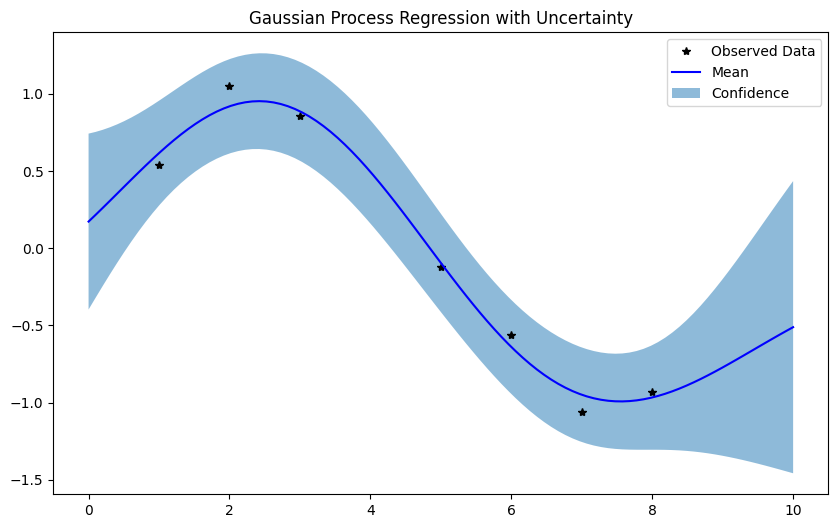

In [6]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Define a simple training dataset
train_x = torch.tensor([1, 2, 3, 5, 6, 7, 8], dtype=torch.float32)
train_y = torch.sin(train_x * (2 * np.pi) / 10) + torch.randn(train_x.size()) * 0.1

# Define the Gaussian Process Model
class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModel(train_x, train_y, likelihood)

# Find optimal model hyperparameters
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for _ in range(100):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

# Set into eval mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,10]
test_x = torch.linspace(0, 10, 100)
# Get into evaluation (predictive posterior) mode
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

# Mean and variance as numpy arrays
mean = observed_pred.mean.numpy()
lower, upper = observed_pred.confidence_region()  # 2 std devs above and below the mean

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_x.numpy(), train_y.numpy(), 'k*', label='Observed Data')
plt.plot(test_x.numpy(), mean, 'b', label='Mean')
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5, label='Confidence')
plt.legend()
plt.title('Gaussian Process Regression with Uncertainty')
plt.show()


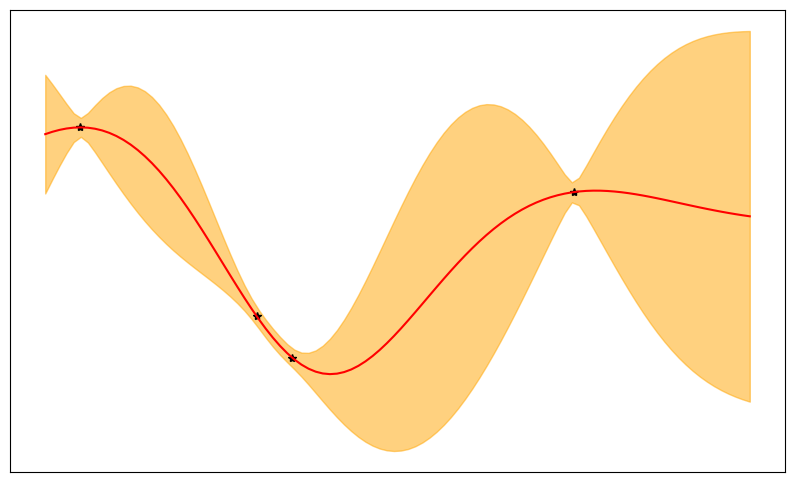

In [41]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Define a simple training dataset
#train_x = torch.tensor([1, 2, 3, 5, 6, 7, 8], dtype=torch.float32)
train_x = torch.tensor([1, 6, 7, 15], dtype=torch.float32)
train_y = torch.sin(train_x * (2 * np.pi) / 10) + torch.randn(train_x.size()) * 0.1

# Define the Gaussian Process Model
class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModel(train_x, train_y, likelihood)

# Set a smaller length scale
model.covar_module.base_kernel.lengthscale = 0.5

# Find optimal model hyperparameters
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1.5)  # Includes GaussianLikelihood parameters
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for _ in range(100):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

# Set into eval mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,10]
test_x = torch.linspace(0, 20, 100)
# Get into evaluation (predictive posterior) mode
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

# Mean and variance as numpy arrays
mean = observed_pred.mean.numpy()
lower, upper = observed_pred.confidence_region()  # 2 std devs above and below the mean

# Plot
plt.figure(figsize=(10, 6))
plt.grid(True)
plt.plot(train_x.numpy(), train_y.numpy(), 'k*', label='Observed Data')
plt.plot(test_x.numpy(), mean, 'r', label='Mean')  # Change line color to red
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), color='orange', alpha=0.5, label='Confidence')  # Change fill color to orange
#plt.legend()
#plt.title('Gaussian Process Regression with Dramatic Uncertainty')
# Turn off x and y axis numbering
plt.xticks([])
plt.yticks([])
plt.savefig('GP_fig.png')
plt.show()


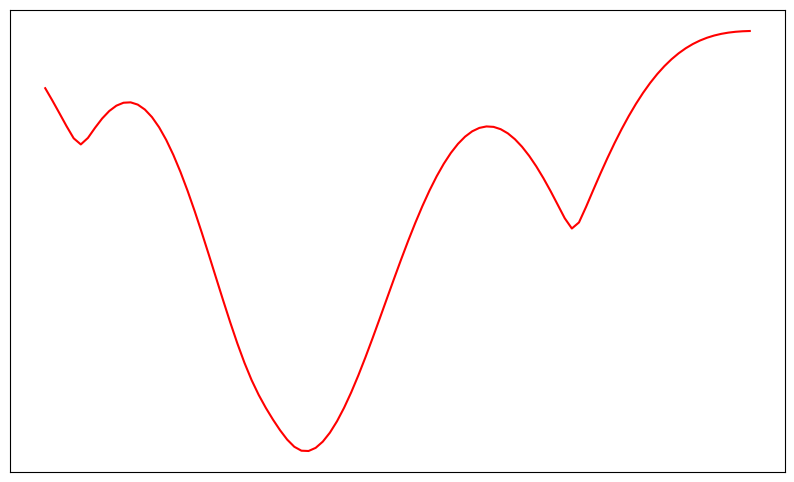

In [42]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# Assuming the GP model, likelihood, and training procedure have been defined and executed as per previous setups

# Define test points regularly spaced along [0,10]
test_x = torch.linspace(0, 20, 100)
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Get predictive distribution
    predicted_dist = likelihood(model(test_x))
    mean = predicted_dist.mean
    std_dev = predicted_dist.variance.sqrt()

# Define the UCB acquisition function
kappa = 2.0  # Exploration-exploitation trade-off parameter
ucb = mean + kappa * std_dev

# Plot UCB on a separate plot
plt.figure(figsize=(10, 6))
plt.plot(test_x.numpy(), ucb.numpy(), 'r-', label='UCB (Upper Confidence Bound)')
#plt.fill_between(test_x.numpy(), (mean - 2 * std_dev).numpy(), (mean + 2 * std_dev).numpy(), color='orange', alpha=0.3, label='95% Confidence Interval')
#plt.xlabel("Input x")
#plt.ylabel("UCB Value")
# plt.legend(loc="upper left")
# plt.title("Upper Confidence Bound (UCB) Across Test Points")
plt.grid(True)
plt.xticks([])
plt.yticks([])
plt.savefig('GP_UCB.png')
plt.show()
